# Introduction

#### Handwritten Digit Recognition
The goal: Take an image of a handwritten single digit, and determine what that digit is.

# Import and Setup

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
import sys
import os

os.chdir('/content/drive/MyDrive/digit_recognizer/data')
sys.path.append('/content/drive/MyDrive/digit_recognizer')
drive.mount('/content/drive')

from src.clean_data import normalize

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Load data

In [20]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(train.head(5))

   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0         0         

# Data cleaning

In [21]:
print('Train minimum value:',np.min(train))
print('Train maximum value:',np.max(train))
print('Test minimum value:',np.min(test))
print('Test maximum value:',np.max(test))
print('Train null count:', train.isnull().sum().sum())
print('Test null count:', test.isnull().sum().sum())
print('Train duplicated:', train.duplicated().sum())
print('Test duplicated:', test.duplicated().sum())

Train minimum value: 0
Train maximum value: 255
Test minimum value: 0
Test maximum value: 255
Train null count: 0
Test null count: 0
Train duplicated: 0
Test duplicated: 0


In [22]:
# This cell find images is filled with single color
threshold = 0.1

print('Train images count:', (train.std(axis=1) < threshold).sum())
print('Test images count:', (test.std(axis=1) < threshold).sum())

Train images count: 0
Test images count: 0


In [23]:
# This cell normalized pixel values to [0,1] on both train and test

normalize(train, test)

# Visualize

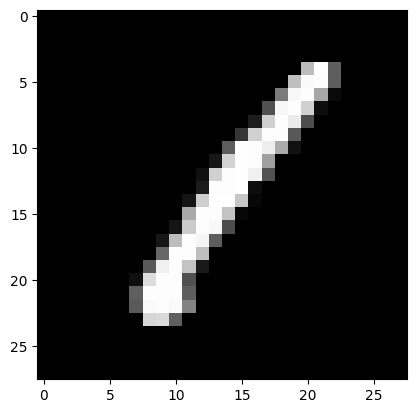

In [24]:
# This cell use to visualize pixels to image
image = train.iloc[0, 1:].values.astype('float32').reshape(28, 28)
plt.imshow(image, cmap='gray')
plt.show()

,count
label,
0,4132
1,4684
2,4177
3,4351
4,4072
5,3795
6,4137
7,4401
8,4063


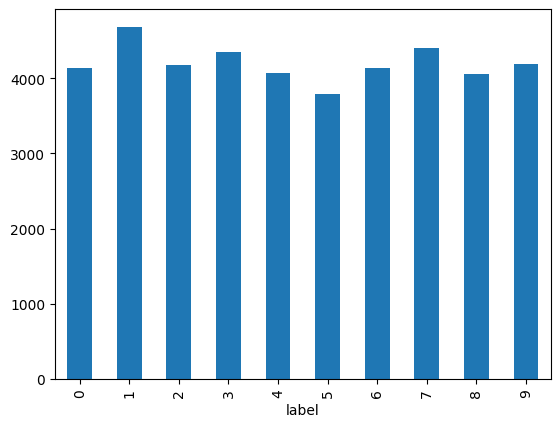

In [25]:
# This cell use to check label balance
train.iloc[:, 0].value_counts().sort_index().plot(kind='bar')
train.iloc[:, 0].value_counts().sort_index()